In [1]:
import os
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path

from dotenv import load_dotenv
from supabase import create_client
import torch
import torch.nn as nn
from torch.utils.data import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from sentence_transformers import SentenceTransformer

from sklearn.model_selection import StratifiedKFold, cross_val_predict, train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

# Seed for reproducibility
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

print("Seed set to:", SEED)
print("Device:", device)

/Users/edgarriosnegrete/Healthcare-GPT/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Seed set to: 42
Device: mps


# Load the data from Supabase

In [2]:
load_dotenv(Path.cwd().parent / ".env")

SUPABASE_URL = os.environ["SUPABASE_URL"]
SUPABASE_KEY = os.environ["SUPABASE_KEY"]
supabase = create_client(SUPABASE_URL, SUPABASE_KEY)

TABLE = "lablr"
PAGE_SIZE = 1000 

rows = []
start = 0
pages = 0
while True:
    resp = (
        supabase.table(TABLE)
        .select("*")
        .range(start, start + PAGE_SIZE - 1)
        .execute()
    )
    batch = resp.data
    if not batch:
        break
    rows.extend(batch)
    pages+=1
    if len(batch) < PAGE_SIZE:
        break
    start += PAGE_SIZE

df_lablr = pd.DataFrame(rows)
print(f"Pulled {len(df_lablr)} rows ({pages} pages) from '{TABLE}'")

Pulled 5465 rows (6 pages) from 'lablr'


In [3]:
df_lablr.head()

,id,entry_id,title,source_name,assigned_subsector,geography_scope,exec_summary,content,subsector_data,raw,approved,chosen_subsector,is_reclassified,reviewer_id,created_at
0,1364,7a32eed99bbe5d05,"COVID updates, Sept. 28: Quebec to administer ...",montrealgazette.com,other,US,Alberta's hospitals are dealing with a crisis ...,"Updated throughout the day on Tuesday, Sept. 2...","{'severity': 'null', 'event_type': 'null', 'be...","{'id': '7a32eed99bbe5d05', 'title': 'COVID upd...",True,other,False,Hunter,2026-06-30T22:28:05.822032+00:00
1,1365,094dcb0b643d0d82,Cybersecurity expert discusses situation at CHI,ketv.com,cyber_attack,NaN,CHI Health shut down some IT systems as a prec...,CHI Health shut down some IT systems as a prec...,"{'attack_type': 'cyber security issue', 'ranso...","{'id': '094dcb0b643d0d82', 'title': 'Cybersecu...",False,NaN,False,Briana,2026-06-30T22:28:14.056715+00:00
2,1564,0e1dd9a47b3f79f3,MI hospitals forced to send patients out of st...,wxyz.com,other,Michigan,Hospitals in Michigan are canceling surgeries ...,DETROIT (WXYZ) — Patients are being sent out o...,"{'severity': None, 'event_type': None, 'beds_o...","{'id': '0e1dd9a47b3f79f3', 'title': 'MI hospit...",False,NaN,False,Briana,2026-06-30T22:46:19.33946+00:00
3,1566,0ea76df689d90a4d,Hackers are extorting Globe Life with stolen c...,techcrunch.com,cyber_attack,US,Insurance giant Globe Life is being extorted b...,"Insurance giant Globe Life, which provides lif...","{'attack_type': 'extortion-only attack', 'rans...","{'id': '0ea76df689d90a4d', 'title': 'Hackers a...",True,cyber_attack,False,Briana,2026-06-30T22:46:39.642885+00:00
4,1605,01bedc1e3108ebbc,"US Fertility Sued Over Ransomware Attack, Heal...",healthitsecurity.com,cyber_attack,US,US Fertility (USF) has been sued by individual...,Getty Images\n\nUS Fertility (USF) has been su...,"{'attack_type': 'Ransomware', 'ransom_paid': F...","{'id': '01bedc1e3108ebbc', 'title': 'US Fertil...",True,cyber_attack,False,Evan,2026-07-01T15:57:22.943771+00:00


### Consts and helper functions

In [4]:
EMBED_MODEL = "all-MiniLM-L6-v2"
embedder = SentenceTransformer(EMBED_MODEL, device=device)

CLASS_NAMES = ["noise", "drug_shortage", "medical_device_shortage", "cyber_attack", "natural_disaster", "other"]

LABEL_MAP = {
    "noise": 0,
    "drug_shortage": 1,
    "medical_device_shortage": 2,
    "cyber_attack": 3,
    "natural_disaster": 4,
    "other": 5
}

IDX_TO_LABEL = {
    0: "noise",
    1: "drug_shortage",
    2: "medical_device_shortage",
    3: "cyber_attack",
    4: "natural_disaster",
    5: "other"
}

DROP_COLS = [
    "entry_id", "assigned_subsector", "raw", "chosen_subsector",
    "is_reclassified", "reviewer_id", "created_at", "approved"
]

X_COLS= ["title", "source_name", "content"]

def _derive_target(row):
    """
    Make a new label and class given a supabase row

    Args:
        row (straight from supabase)

    Returns:
        'label' and 'map' series with the correct classification
        If 'chosen_subsector' is not in LABEL_MAP returns nan pair
    """
    if not row["approved"]:
        return pd.Series({"label": 0, "class": "noise"})
    sub = row["chosen_subsector"]
    if sub in LABEL_MAP:
        return pd.Series({"label": LABEL_MAP[sub], "class": sub})
    return pd.Series({"label": np.nan, "class": np.nan}) 

In [5]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)


df = df_lablr.copy()
df[["label", "class"]] = df.apply(_derive_target, axis=1) # axis 1 needed for cols

# drop unmapped edge-case rows, then lock label to int
df = df[df["label"].notna()].copy()
df["label"] = df["label"].astype(int) # make sure label is int
df = df.drop(columns=DROP_COLS)

df["class"].value_counts()

class
cyber_attack               2349
noise                      1593
other                       739
drug_shortage               432
natural_disaster            303
medical_device_shortage      49
Name: count, dtype: int64

# Classis models

### Use `all-MiniLM-L6-v2` to convert all the text (used for classic models)

In [7]:
text = df[X_COLS].fillna("").astype(str).agg("\n".join, axis=1)

# X = df[X_COLS]
X_classic = embedder.encode(
    text.tolist(),
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True,
)
y = df["label"].to_numpy() #just 2 b safe

X_classic.shape

Batches: 100%|██████████| 86/86 [00:20<00:00,  4.24it/s]


(5465, 384)

In [8]:
def _make_pipe(clf) -> Pipeline:
    """
    Used to prep every model the same way before training

    Args:
        clf: the different classifiers used
    Returns:
        Pipeline object with the same specs
    """
    return Pipeline([
        ("scale", StandardScaler()), # req for LR/SVC/MLP, RF doesn't need it but still gets it
        ("clf", clf),
    ])


def classic_models():
    """
    Returns:
        a fresh dict of NEW, untrained pipeline instances every call
    """
    return {
        "RandomForest": _make_pipe(RandomForestClassifier(random_state=SEED)),
        "LogisticRegression": _make_pipe(LogisticRegression(max_iter=1000, random_state=SEED)),
        "SVC": _make_pipe(SVC(random_state=SEED)),
        "MLP": _make_pipe(MLPClassifier(max_iter=1000, random_state=SEED)),
    }

In [9]:
def run_experiment(X, y, models = classic_models()):
  """

  """
  results = {} # name = (mean_acc, std_acc)

  for name, pipe in models.items():
      print("="*75)
      print(name)

      #collects each window's out-of-fold prediction
      y_pred = cross_val_predict(pipe, X, y, cv=cv)

      # get a np array of scores
      scores = np.array([accuracy_score(y[test], y_pred[test]) for _, test in cv.split(X, y)])
      # used to be: `scores = cross_val_score(pipe, X, y, cv=cv, scoring="accuracy")`
      results[name] = (scores.mean(), scores.std()) # save 1 score mean with std

      print(f"Accuracy per fold: {np.round(scores, 4)}")
      print(f"Mean accuracy: {scores.mean():.4f} ± {scores.std():.4f}")

      print("\nClassification report (out-of-fold):")
      print(classification_report(y, y_pred, target_names=CLASS_NAMES))

      # confusion matrix
      cm = confusion_matrix(y, y_pred, labels=range(len(CLASS_NAMES)))
      plt.figure(figsize=(5, 4))
      sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
      plt.title(f"{name} -- out-of-fold confusion matrix")
      plt.xlabel("Predicted")
      plt.ylabel("True")
      plt.show()
      print("="*75)


  print("Summary -- algorithms ranked by mean 5-fold accuracy")
  print("-"*60)
  ranking = sorted(results.items(), key=lambda kv: kv[1][0], reverse=True)
  for rank, (name, (mean_acc, std_acc)) in enumerate(ranking, start=1):
    print(f"{rank}. {name:<20} {mean_acc:.4f} ± {std_acc:.4f}")
    

RandomForest
Accuracy per fold: [0.6825 0.6752 0.688  0.656  0.6734]
Mean accuracy: 0.6750 ± 0.0109

Classification report (out-of-fold):
                         precision    recall  f1-score   support

                  noise       0.51      0.38      0.43      1593
          drug_shortage       0.80      0.74      0.76       432
medical_device_shortage       0.00      0.00      0.00        49
           cyber_attack       0.73      0.91      0.81      2349
       natural_disaster       0.79      0.40      0.53       303
                  other       0.62      0.68      0.65       739

               accuracy                           0.68      5465
              macro avg       0.57      0.52      0.53      5465
           weighted avg       0.65      0.68      0.65      5465



/Users/edgarriosnegrete/Healthcare-GPT/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/edgarriosnegrete/Healthcare-GPT/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/edgarriosnegrete/Healthcare-GPT/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(

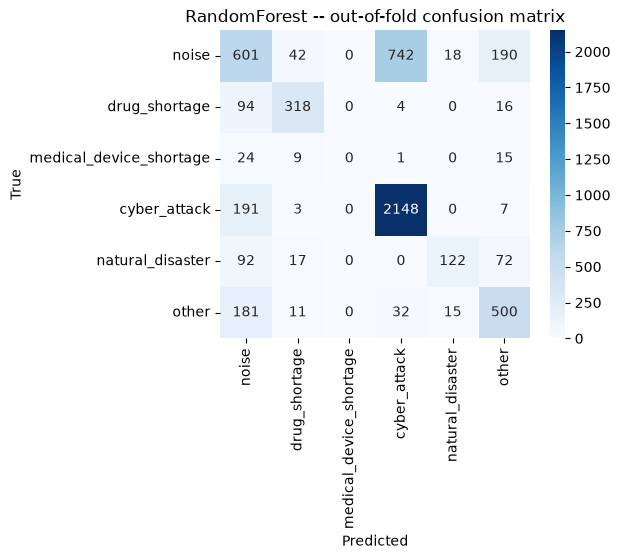

LogisticRegression
Accuracy per fold: [0.6615 0.6597 0.6642 0.6578 0.6349]
Mean accuracy: 0.6556 ± 0.0106

Classification report (out-of-fold):
                         precision    recall  f1-score   support

                  noise       0.49      0.41      0.45      1593
          drug_shortage       0.75      0.75      0.75       432
medical_device_shortage       0.26      0.31      0.28        49
           cyber_attack       0.75      0.82      0.78      2349
       natural_disaster       0.61      0.64      0.63       303
                  other       0.62      0.63      0.62       739

               accuracy                           0.66      5465
              macro avg       0.58      0.59      0.59      5465
           weighted avg       0.64      0.66      0.65      5465



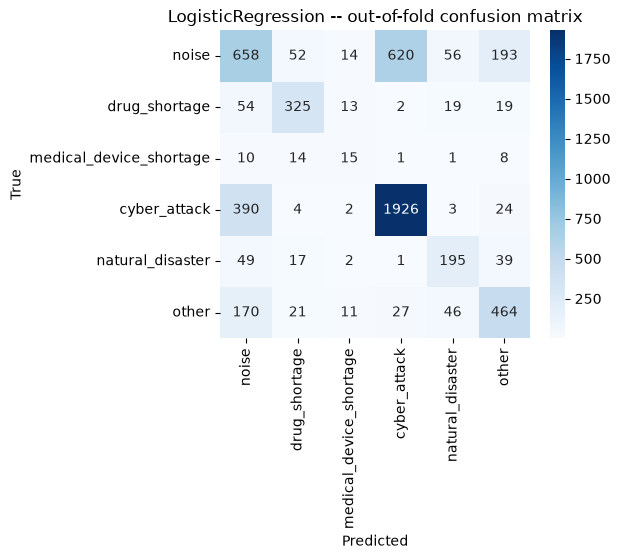

SVC
Accuracy per fold: [0.7264 0.7063 0.72   0.7118 0.7155]
Mean accuracy: 0.7160 ± 0.0069

Classification report (out-of-fold):
                         precision    recall  f1-score   support

                  noise       0.60      0.38      0.46      1593
          drug_shortage       0.77      0.84      0.81       432
medical_device_shortage       1.00      0.14      0.25        49
           cyber_attack       0.75      0.93      0.83      2349
       natural_disaster       0.73      0.74      0.73       303
                  other       0.69      0.72      0.71       739

               accuracy                           0.72      5465
              macro avg       0.76      0.63      0.63      5465
           weighted avg       0.70      0.72      0.69      5465



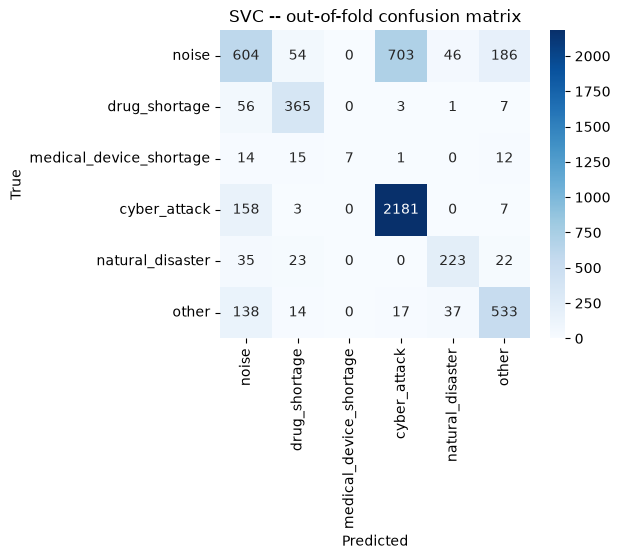

MLP
Accuracy per fold: [0.6834 0.6798 0.6715 0.6706 0.6423]
Mean accuracy: 0.6695 ± 0.0145

Classification report (out-of-fold):
                         precision    recall  f1-score   support

                  noise       0.50      0.44      0.47      1593
          drug_shortage       0.76      0.80      0.78       432
medical_device_shortage       0.41      0.24      0.31        49
           cyber_attack       0.75      0.81      0.78      2349
       natural_disaster       0.69      0.70      0.69       303
                  other       0.65      0.66      0.65       739

               accuracy                           0.67      5465
              macro avg       0.63      0.61      0.61      5465
           weighted avg       0.66      0.67      0.66      5465



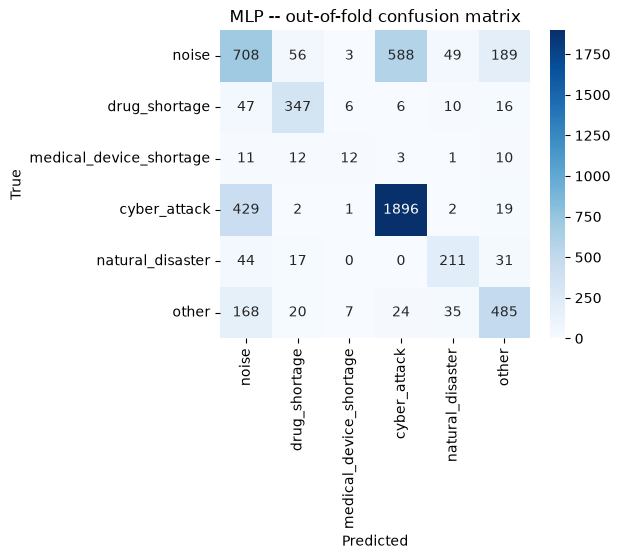

Summary -- algorithms ranked by mean 5-fold accuracy
------------------------------------------------------------
1. SVC                  0.7160 ± 0.0069
2. RandomForest         0.6750 ± 0.0109
3. MLP                  0.6695 ± 0.0145
4. LogisticRegression   0.6556 ± 0.0106


In [10]:
run_experiment(X_classic,y)

# BERT

In [11]:
#bert_path = "google-bert/bert-base-uncased"
bert_path = "microsoft/deberta-v3-base"

tokenizer = AutoTokenizer.from_pretrained(bert_path)

model = AutoModelForSequenceClassification.from_pretrained(
    bert_path,
    num_labels = 6,
    id2label = IDX_TO_LABEL,
    label2id = LABEL_MAP,
)

/Users/edgarriosnegrete/Healthcare-GPT/.venv/lib/python3.12/site-packages/transformers/convert_slow_tokenizer.py:566: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(
Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [12]:
MAX_LEN = 256  # same window MiniLM effectively saw; bump to 512 later if curious (2x slower)

bert_texts = text.tolist()  # same input text as the classic models

train_idx, val_idx = train_test_split(
    np.arange(len(bert_texts)), test_size=0.2, stratify=y, random_state=SEED
)

class LablrDataset(Dataset):
    def __init__(self, texts, labels):
        self.enc = tokenizer(texts, truncation=True, max_length=MAX_LEN)
        self.labels = labels
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, i):
        item = {k: v[i] for k, v in self.enc.items()}
        item["labels"] = int(self.labels[i])
        return item

train_ds = LablrDataset([bert_texts[i] for i in train_idx], y[train_idx])
val_ds = LablrDataset([bert_texts[i] for i in val_idx],  y[val_idx])
print(len(train_ds), "train /", len(val_ds), "val")


4372 train / 1093 val


In [13]:
from sklearn.metrics import f1_score
from sklearn.utils.class_weight import compute_class_weight

class_weights = torch.tensor(
    compute_class_weight("balanced", classes=np.arange(len(CLASS_NAMES)), y=y[train_idx]),
    dtype=torch.float32,
)

def weighted_loss(outputs, labels, num_items_in_batch=None):
    return nn.functional.cross_entropy(
        outputs.logits, labels, weight=class_weights.to(outputs.logits.device)
    )

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "macro_f1": f1_score(labels, preds, average="macro"),
    }


In [14]:
training_args = TrainingArguments(
    output_dir="../src/models/bert_lablr", 
    learning_rate=2e-5, 
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=4,
    weight_decay=0.01,
    warmup_ratio=0.1,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    logging_steps=25,
    report_to="none",
    seed=SEED,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
    compute_loss_func=weighted_loss,
)

trainer.train()


The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 2, 'bos_token_id': 1}.
/Users/edgarriosnegrete/Healthcare-GPT/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,1.207700,1.165664,0.675206,0.538929
2,0.842200,1.025623,0.645014,0.516209
3,0.838000,0.877179,0.686185,0.548924
4,0.754200,0.852340,0.709058,0.591599


/Users/edgarriosnegrete/Healthcare-GPT/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/Users/edgarriosnegrete/Healthcare-GPT/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/Users/edgarriosnegrete/Healthcare-GPT/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


TrainOutput(global_step=1096, training_loss=0.9413129273992386, metrics={'train_runtime': 2591.387, 'train_samples_per_second': 6.749, 'train_steps_per_second': 0.423, 'total_flos': 2300766953619456.0, 'train_loss': 0.9413129273992386, 'epoch': 4.0})

/Users/edgarriosnegrete/Healthcare-GPT/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


BERT holdout acc: 0.7091 | macro F1: 0.5916
                         precision    recall  f1-score   support

                  noise       0.61      0.25      0.36       318
          drug_shortage       0.77      0.90      0.83        86
medical_device_shortage       0.00      0.00      0.00        10
           cyber_attack       0.73      0.93      0.82       470
       natural_disaster       0.67      0.92      0.78        61
                  other       0.71      0.84      0.77       148

               accuracy                           0.71      1093
              macro avg       0.58      0.64      0.59      1093
           weighted avg       0.69      0.71      0.67      1093



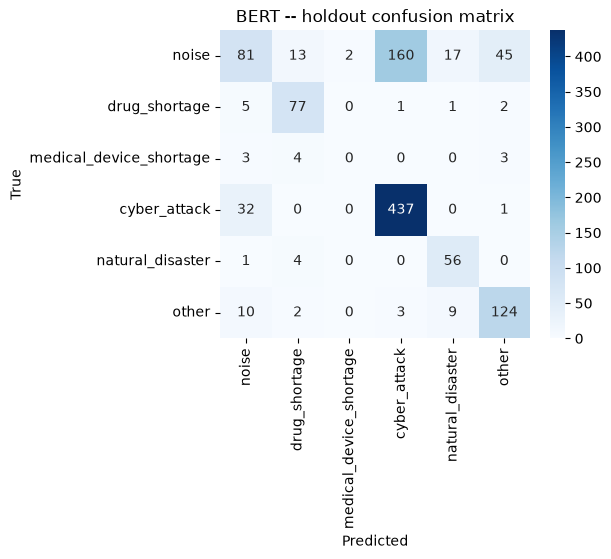

In [15]:
pred = trainer.predict(val_ds)
y_val_true = y[val_idx]
y_val_pred = pred.predictions.argmax(axis=-1)

print(f"BERT holdout acc: {accuracy_score(y_val_true, y_val_pred):.4f}"
      f" | macro F1: {f1_score(y_val_true, y_val_pred, average='macro'):.4f}")
print(classification_report(y_val_true, y_val_pred,
      labels=range(len(CLASS_NAMES)), target_names=CLASS_NAMES, zero_division=0))

cm = confusion_matrix(y_val_true, y_val_pred, labels=range(len(CLASS_NAMES)))
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title("BERT -- holdout confusion matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


In [ ]:
# Accuacy based on Gemma here:
# =============================================================================
# LLM baseline on the SAME val split BERT tests on -- frozen + resumable.
#
# Calls src/shared_utils.ai_check_validation (the production prompt/config,
# verbatim -- incl. temperature=1, so expect ~1-2pt run-to-run variance) for
# each model in MODELS. Models missing from local Ollama are skipped with a
# message, so this exact cell runs unchanged on the machine that has gemma.
#
# NOTE: production passes only (title, body[:BODY_CHAR_LIMIT]) to the LLM --
# no source_name, unlike the text the BERT/classic models see.
#
# Predictions append per-row to data/llm_baseline/preds_{model}.csv, so
# interrupting and re-running resumes where it left off. The val chunk itself
# is frozen to data/llm_baseline/val_split.csv on first run (ids + labels
# only); copy that folder to the other machine so every model is scored on the
# identical rows/labels even if lablr grows in between.
# =============================================================================
import csv
import sys
import time
from datetime import datetime, timezone

from sklearn.metrics import f1_score, precision_score, recall_score
from tqdm.auto import tqdm

sys.path.insert(0, str(Path.cwd().parent))

import src.shared_utils as su
from src.shared_utils import (
    LLMUnavailableError,
    ai_check_validation,
    ensure_model_available,
    model_unavailable_error,
)

MODELS = ["llama3.2:latest", "gemma4:e4b"]
PORT = 11434
N_LIMIT = None  # e.g. 25 for a quick smoke pass; None = the full val chunk
MAX_ATTEMPTS = 3  # attempts per article on LLMUnavailableError

OUT_DIR = Path.cwd().parent / "data" / "llm_baseline"
OUT_DIR.mkdir(parents=True, exist_ok=True)
SPLIT_CSV = OUT_DIR / "val_split.csv"
VALID_SUBSECTORS = set(CLASS_NAMES) - {"noise"}
PRED_COLS = ["id", "model", "pred_class", "is_disruption", "detail", "latency_s", "ts"]

# ---- 1. Freeze / load the val chunk -----------------------------------------
if "df" not in globals():
    raise RuntimeError("Run the notebook cells above first (need the lablr pull for article text).")

if SPLIT_CSV.exists():
    split_df = pd.read_csv(SPLIT_CSV)
    print(f"Loaded frozen val split ({len(split_df)} rows) from {SPLIT_CSV}")
else:
    if "val_idx" not in globals():
        raise RuntimeError(
            "No frozen split at data/llm_baseline/val_split.csv -- "
            "run the BERT split cell above first so val_idx exists."
        )
    split_df = df.iloc[val_idx][["id", "title"]].copy()
    split_df["label"] = y[val_idx]
    split_df["class"] = split_df["label"].map(IDX_TO_LABEL)
    split_df.to_csv(SPLIT_CSV, index=False)
    print(f"Froze val split ({len(split_df)} rows) -> {SPLIT_CSV}")

# article text comes fresh from the in-session lablr pull (bodies aren't stored
# in the frozen CSV); the frozen labels always win over current lablr state
_texts = df.drop_duplicates("id").set_index("id")[["title", "content"]]
_lost = ~split_df["id"].isin(_texts.index)
if _lost.any():
    print(f"[warn] {int(_lost.sum())} frozen id(s) missing from current lablr pull -- skipped")
eval_df = split_df.loc[~_lost, ["id", "label", "class"]].copy()
eval_df["title"] = eval_df["id"].map(_texts["title"]).fillna("")
eval_df["content"] = eval_df["id"].map(_texts["content"]).fillna("")

# ---- 2. Resumable eval loop --------------------------------------------------
def _preds_path(model_tag: str) -> Path:
    return OUT_DIR / f"preds_{model_tag.replace(':', '_').replace('/', '_')}.csv"

def run_llm_eval(model_tag: str, rows: pd.DataFrame, n_limit: int | None = None) -> None:
    """Run ai_check_validation over rows, appending each result to the preds CSV."""
    path = _preds_path(model_tag)
    done = set(pd.read_csv(path, usecols=["id"])["id"]) if path.exists() else set()

    try:
        ensure_model_available(model_tag)
    except model_unavailable_error as exc:
        print(f"[skip] {model_tag} -- {exc}\n       (run this cell on the machine that has it)")
        return

    todo = rows[~rows["id"].isin(done)]
    if n_limit is not None:
        todo = todo.iloc[: max(0, n_limit - len(done))]
    print(f"{model_tag}: {len(done)} already recorded, {len(todo)} to run")
    if todo.empty:
        return

    su.AI_MODEL = model_tag  # ai_check_validation reads this module global at call time
    new_file = not path.exists()
    with open(path, "a", newline="", encoding="utf-8") as fh:
        writer = csv.writer(fh)
        if new_file:
            writer.writerow(PRED_COLS)
        for row in tqdm(todo.itertuples(index=False), total=len(todo), desc=model_tag):
            body = str(row.content)[: su.BODY_CHAR_LIMIT]  # same truncation as runner.py
            is_disruption, detail, pred = None, "", "error"
            t0 = time.perf_counter()
            for attempt in range(MAX_ATTEMPTS):
                try:
                    is_disruption, detail = ai_check_validation(str(row.title), body, port=PORT)
                    if is_disruption:
                        pred = detail if detail in VALID_SUBSECTORS else "invalid"
                    else:
                        pred = "noise"
                    break
                except LLMUnavailableError as exc:
                    detail = str(exc)
                    if attempt < MAX_ATTEMPTS - 1:
                        time.sleep(5)
            writer.writerow([
                row.id,
                model_tag,
                pred,
                is_disruption,
                " ".join(str(detail).split())[:300],
                round(time.perf_counter() - t0, 2),
                datetime.now(timezone.utc).isoformat(timespec="seconds"),
            ])
            fh.flush()

for _m in MODELS:
    run_llm_eval(_m, eval_df, N_LIMIT)

# ---- 3. Score every model that has predictions on disk -----------------------
_summary = []
for _m in MODELS:
    _path = _preds_path(_m)
    if not _path.exists():
        continue
    _preds = pd.read_csv(_path).drop_duplicates("id", keep="last")
    _merged = split_df.merge(_preds[["id", "pred_class"]], on="id", how="inner")
    _n_err = int((_merged["pred_class"] == "error").sum())
    _n_inv = int((_merged["pred_class"] == "invalid").sum())
    _merged = _merged[_merged["pred_class"] != "error"]
    if _merged.empty:
        continue
    _y_true = _merged["label"].to_numpy()
    # production drops invalid-subsector responses (never published) -> score as noise
    _y_pred = _merged["pred_class"].replace("invalid", "noise").map(LABEL_MAP).to_numpy()

    _acc = accuracy_score(_y_true, _y_pred)
    _mf1 = f1_score(_y_true, _y_pred, average="macro")
    _gp = precision_score(_y_true != 0, _y_pred != 0, zero_division=0)
    _gr = recall_score(_y_true != 0, _y_pred != 0, zero_division=0)

    print("=" * 75)
    print(f"{_m} -- n={len(_merged)} (errors dropped: {_n_err}, invalid scored as noise: {_n_inv})")
    print(f"accuracy: {_acc:.4f} | macro F1: {_mf1:.4f} | gate precision: {_gp:.4f} | gate recall: {_gr:.4f}")
    print(classification_report(_y_true, _y_pred, labels=range(len(CLASS_NAMES)), target_names=CLASS_NAMES, zero_division=0))
    _cm = confusion_matrix(_y_true, _y_pred, labels=range(len(CLASS_NAMES)))
    plt.figure(figsize=(5, 4))
    sns.heatmap(_cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.title(f"{_m} -- val-split confusion matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()
    _summary.append({"model": _m, "n": len(_merged), "accuracy": _acc, "macro_f1": _mf1, "gate_precision": _gp, "gate_recall": _gr})

# side-by-side with the in-session BERT holdout, when the BERT cells have run
if "y_val_pred" in globals() and "y_val_true" in globals():
    _summary.append({
        "model": f"BERT ({bert_path})" if "bert_path" in globals() else "BERT",
        "n": len(y_val_true),
        "accuracy": accuracy_score(y_val_true, y_val_pred),
        "macro_f1": f1_score(y_val_true, y_val_pred, average="macro"),
        "gate_precision": precision_score(y_val_true != 0, y_val_pred != 0, zero_division=0),
        "gate_recall": recall_score(y_val_true != 0, y_val_pred != 0, zero_division=0),
    })

if _summary:
    display(
        pd.DataFrame(_summary)
        .sort_values("macro_f1", ascending=False)
        .reset_index(drop=True)
        .round(4)
    )